In [11]:
'''
stringency_index	Hükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)
population_density	Nüfus yoğunluğu (km² başına kişi)
median_age	Medyan yaş
aged_65_older / aged_70_older	Nüfusun 65/70 yaş üstü yüzdesi
gdp_per_capita	Kişi başı GSYH
extreme_poverty	Aşırı yoksulluk oranı
cardiovasc_death_rate	Kardiyovasküler hastalık ölüm oranı
diabetes_prevalence	Diyabet yaygınlığı
female_smokers / male_smokers	Sigara içme oranları (cinsiyete göre)
handwashing_facilities	El yıkama imkanına erişim oranı
hospital_beds_per_thousand	Bin kişiye düşen hastane yatağı
life_expectancy	Ortalama yaşam beklentisi
human_development_index	İnsani gelişmişlik endeksi (HDI)
population	Toplam nüfus
'''

'\nstringency_index\tHükümetin kısıtlama sertliği endeksi (0-100, kapanma/maske zorunluluğu vb.)\npopulation_density\tNüfus yoğunluğu (km² başına kişi)\nmedian_age\tMedyan yaş\naged_65_older / aged_70_older\tNüfusun 65/70 yaş üstü yüzdesi\ngdp_per_capita\tKişi başı GSYH\nextreme_poverty\tAşırı yoksulluk oranı\ncardiovasc_death_rate\tKardiyovasküler hastalık ölüm oranı\ndiabetes_prevalence\tDiyabet yaygınlığı\nfemale_smokers / male_smokers\tSigara içme oranları (cinsiyete göre)\nhandwashing_facilities\tEl yıkama imkanına erişim oranı\nhospital_beds_per_thousand\tBin kişiye düşen hastane yatağı\nlife_expectancy\tOrtalama yaşam beklentisi\nhuman_development_index\tİnsani gelişmişlik endeksi (HDI)\npopulation\tToplam nüfus\n'

In [ ]:
# Ortak yardımcı fonksiyonlarla temiz ülke verisini yüklüyor ve temel kalite kontrolünü yapıyoruz.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data_loader import (
    load_countries,
    print_country_data_overview
)

df_countries = load_countries()
print_country_data_overview(df_countries)


In [13]:
#sabit ülke göstergelerini grupluyoruz
demographic_columns = [
    'population_density',
    'median_age',
    'aged_65_older',
    'aged_70_older'
]

economic_social_columns = [
    'gdp_per_capita',
    'extreme_poverty',
    'handwashing_facilities',
    'life_expectancy',
    'human_development_index'
]

health_risk_columns = [
    'cardiovasc_death_rate',
    'diabetes_prevalence',
    'female_smokers',
    'male_smokers'
]

infrastructure_columns = [
    'hospital_beds_per_thousand'
]

static_profile_columns = (
    demographic_columns
    + economic_social_columns
    + health_risk_columns
    + infrastructure_columns
)

print('İncelenecek sabit ülke göstergeleri:')
print(static_profile_columns)

print('\nVeri türleri:')
print(df_countries[static_profile_columns].dtypes)

İncelenecek sabit ülke göstergeleri:
['population_density', 'median_age', 'aged_65_older', 'aged_70_older', 'gdp_per_capita', 'extreme_poverty', 'handwashing_facilities', 'life_expectancy', 'human_development_index', 'cardiovasc_death_rate', 'diabetes_prevalence', 'female_smokers', 'male_smokers', 'hospital_beds_per_thousand']

Veri türleri:
population_density            float64
median_age                    float64
aged_65_older                 float64
aged_70_older                 float64
gdp_per_capita                float64
extreme_poverty               float64
handwashing_facilities        float64
life_expectancy               float64
human_development_index       float64
cardiovasc_death_rate         float64
diabetes_prevalence           float64
female_smokers                float64
male_smokers                  float64
hospital_beds_per_thousand    float64
dtype: object


In [14]:
#bütün sabit göstergelerin veri kapsamını inceliyoruz.Ne kadarı dolu?
static_coverage = (
    df_countries
    .groupby('location')[static_profile_columns]
    .count()
    .rename(
        columns=lambda column: f'dolu_{column}_kaydi'
    )
)

static_coverage.insert(
    0,
    'toplam_satir',
    df_countries.groupby('location')['date'].size()
)

static_availability = pd.Series({
    column: (
        static_coverage[
            f'dolu_{column}_kaydi'
        ]
        .gt(0)
        .sum()
    )
    for column in static_profile_columns
}).sort_values(ascending=False)

print('Gösterge bazında veri bulunan ülke sayısı:')
print(static_availability)

print('\nİlk 20 ülkenin veri kapsamı:')
print(static_coverage.head(20))

Gösterge bazında veri bulunan ülke sayısı:
life_expectancy               194
diabetes_prevalence           192
population_density            191
human_development_index       187
cardiovasc_death_rate         186
gdp_per_capita                186
median_age                    183
aged_65_older                 182
aged_70_older                 182
hospital_beds_per_thousand    172
female_smokers                146
male_smokers                  144
extreme_poverty               123
handwashing_facilities         95
dtype: int64

İlk 20 ülkenin veri kapsamı:
                     toplam_satir  dolu_population_density_kaydi  \
location                                                           
Afghanistan                  1674                           1674   
Albania                      1674                           1674   
Algeria                      1674                           1674   
Andorra                      1674                           1674   
Angola                       1

In [15]:
#bu değerler gerçekten ülke için sabit mi kontrol ediyoruz
static_value_counts = (
    df_countries
    .groupby('location')[static_profile_columns]
    .nunique()
)

changing_static_values = static_value_counts.loc[
    static_value_counts.gt(1).any(axis=1)
]

print(
    'Zaman içinde en az bir sabit göstergesi değişen ülke sayısı:',
    len(changing_static_values)
)

print(changing_static_values)

Zaman içinde en az bir sabit göstergesi değişen ülke sayısı: 0
Empty DataFrame
Columns: [population_density, median_age, aged_65_older, aged_70_older, gdp_per_capita, extreme_poverty, handwashing_facilities, life_expectancy, human_development_index, cardiovasc_death_rate, diabetes_prevalence, female_smokers, male_smokers, hospital_beds_per_thousand]
Index: []


In [16]:
#sabit göstergeler mantıksal sınırlar çerçevesinde mi kontrol ediyoruz
range_rules = {
    'population_density': (0, None, True),
    'median_age': (0, 120, True),
    'aged_65_older': (0, 100, False),
    'aged_70_older': (0, 100, False),
    'gdp_per_capita': (0, None, True),
    'extreme_poverty': (0, 100, False),
    'handwashing_facilities': (0, 100, False),
    'life_expectancy': (0, 120, True),
    'human_development_index': (0, 1, False),
    'cardiovasc_death_rate': (0, None, True),
    'diabetes_prevalence': (0, 100, False),
    'female_smokers': (0, 100, False),
    'male_smokers': (0, 100, False),
    'hospital_beds_per_thousand': (0, None, True)
}

range_issue_counts = []

for column, (lower, upper, strict_lower) in range_rules.items():
    valid_values = df_countries[column].notna()

    if strict_lower:
        valid_values &= df_countries[column].gt(lower)
    else:
        valid_values &= df_countries[column].ge(lower)

    if upper is not None:
        valid_values &= df_countries[column].le(upper)

    invalid_values = (
        df_countries[column].notna()
        & ~valid_values
    )

    range_issue_counts.append(
        {
            'gosterge': column,
            'anormal_kayit_sayisi': invalid_values.sum()
        }
    )

range_issue_summary = pd.DataFrame(range_issue_counts)

print(
    range_issue_summary.loc[
        range_issue_summary['anormal_kayit_sayisi'] > 0
    ]
)

Empty DataFrame
Columns: [gosterge, anormal_kayit_sayisi]
Index: []


In [17]:
country_profile_columns = [
    'location',
    'iso_code',
    'continent',
    'population'
] + static_profile_columns #her ülke için bir profil çiziyoruz

country_profile = (
    df_countries[country_profile_columns]
    .groupby('location', as_index=False)
    .first()
)

print('Country profile satır-sütun sayısı:', country_profile.shape)

display(country_profile.head())

print('\nProfildeki ülke sayısı:')
print(country_profile['location'].nunique())

Country profile satır-sütun sayısı: (194, 18)


,location,iso_code,continent,population,population_density,median_age,aged_65_older,aged_70_older,gdp_per_capita,extreme_poverty,handwashing_facilities,life_expectancy,human_development_index,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,hospital_beds_per_thousand
0,Afghanistan,AFG,Asia,41128772,54.42,18.6,2.58,1.34,1803.99,NaN,37.75,64.83,0.51,597.03,9.59,NaN,NaN,0.50
1,Albania,ALB,Europe,2842318,104.87,38.0,13.19,8.64,11803.43,1.1,NaN,78.57,0.80,304.20,10.08,7.1,51.2,2.89
2,Algeria,DZA,Africa,44903228,17.35,29.1,6.21,3.86,13913.84,0.5,83.74,76.88,0.75,278.36,6.73,0.7,30.4,1.90
3,Andorra,AND,Europe,79843,163.76,NaN,NaN,NaN,NaN,NaN,NaN,83.73,0.87,109.14,7.97,29.0,37.8,NaN
4,Angola,AGO,Africa,35588996,23.89,16.8,2.40,1.36,5819.50,NaN,26.66,61.15,0.58,276.04,3.94,NaN,NaN,NaN



Profildeki ülke sayısı:
194


In [18]:
#ölüm ve aşılama için en geniş ülkeyi seçiyoruz
death_date_coverage = (
    df_countries.loc[
        df_countries['total_deaths_per_million'].notna(),
        ['location', 'date']
    ]
    .groupby('date')['location']
    .nunique()
)

max_death_country_count = death_date_coverage.max()

death_comparison_date = (
    death_date_coverage[
        death_date_coverage == max_death_country_count
    ]
    .index
    .max()
)

vaccination_date_coverage = (
    df_countries.loc[
        df_countries[
            'people_fully_vaccinated_per_hundred'
        ].notna(),
        ['location', 'date']
    ]
    .groupby('date')['location']
    .nunique()
)

max_vaccination_country_count = (
    vaccination_date_coverage.max()
)

vaccination_comparison_date = (
    vaccination_date_coverage[
        vaccination_date_coverage
        == max_vaccination_country_count
    ]
    .index
    .max()
)

print(
    'Ölüm karşılaştırma tarihi:',
    death_comparison_date
)

print(
    'Ölüm karşılaştırmasındaki ülke sayısı:',
    max_death_country_count
)

print(
    'Tam aşılama karşılaştırma tarihi:',
    vaccination_comparison_date
)

print(
    'Tam aşılama karşılaştırmasındaki ülke sayısı:',
    max_vaccination_country_count
)

Ölüm karşılaştırma tarihi: 2024-08-04 00:00:00
Ölüm karşılaştırmasındaki ülke sayısı: 194
Tam aşılama karşılaştırma tarihi: 2021-08-16 00:00:00
Tam aşılama karşılaştırmasındaki ülke sayısı: 106


In [19]:
death_outcome = (
    df_countries.loc[
        df_countries['date'] == death_comparison_date,
        [
            'location',
            'total_deaths_per_million'
        ]
    ]
    .copy()
)

vaccination_outcome = (
    df_countries.loc[
        df_countries['date'] == vaccination_comparison_date,
        [
            'location',
            'people_fully_vaccinated_per_hundred'
        ]
    ]
    .copy()
)

gdp_death_data = (
    country_profile[
        [
            'location',
            'gdp_per_capita'
        ]
    ]
    .merge(
        death_outcome,
        on='location',
        how='inner'
    )
    .dropna()
)

age_death_data = (
    country_profile[
        [
            'location',
            'aged_65_older'
        ]
    ]
    .merge(
        death_outcome,
        on='location',
        how='inner'
    )
    .dropna()
)

hdi_vaccination_data = (
    country_profile[
        [
            'location',
            'human_development_index'
        ]
    ]
    .merge(
        vaccination_outcome,
        on='location',
        how='inner'
    )
    .dropna()
)

print('GDP–ölüm karşılaştırılan ülke sayısı:', len(gdp_death_data))
print('65 yaş üstü–ölüm karşılaştırılan ülke sayısı:', len(age_death_data))
print('HDI–tam aşılama karşılaştırılan ülke sayısı:', len(hdi_vaccination_data))

GDP–ölüm karşılaştırılan ülke sayısı: 186
65 yaş üstü–ölüm karşılaştırılan ülke sayısı: 182
HDI–tam aşılama karşılaştırılan ülke sayısı: 105


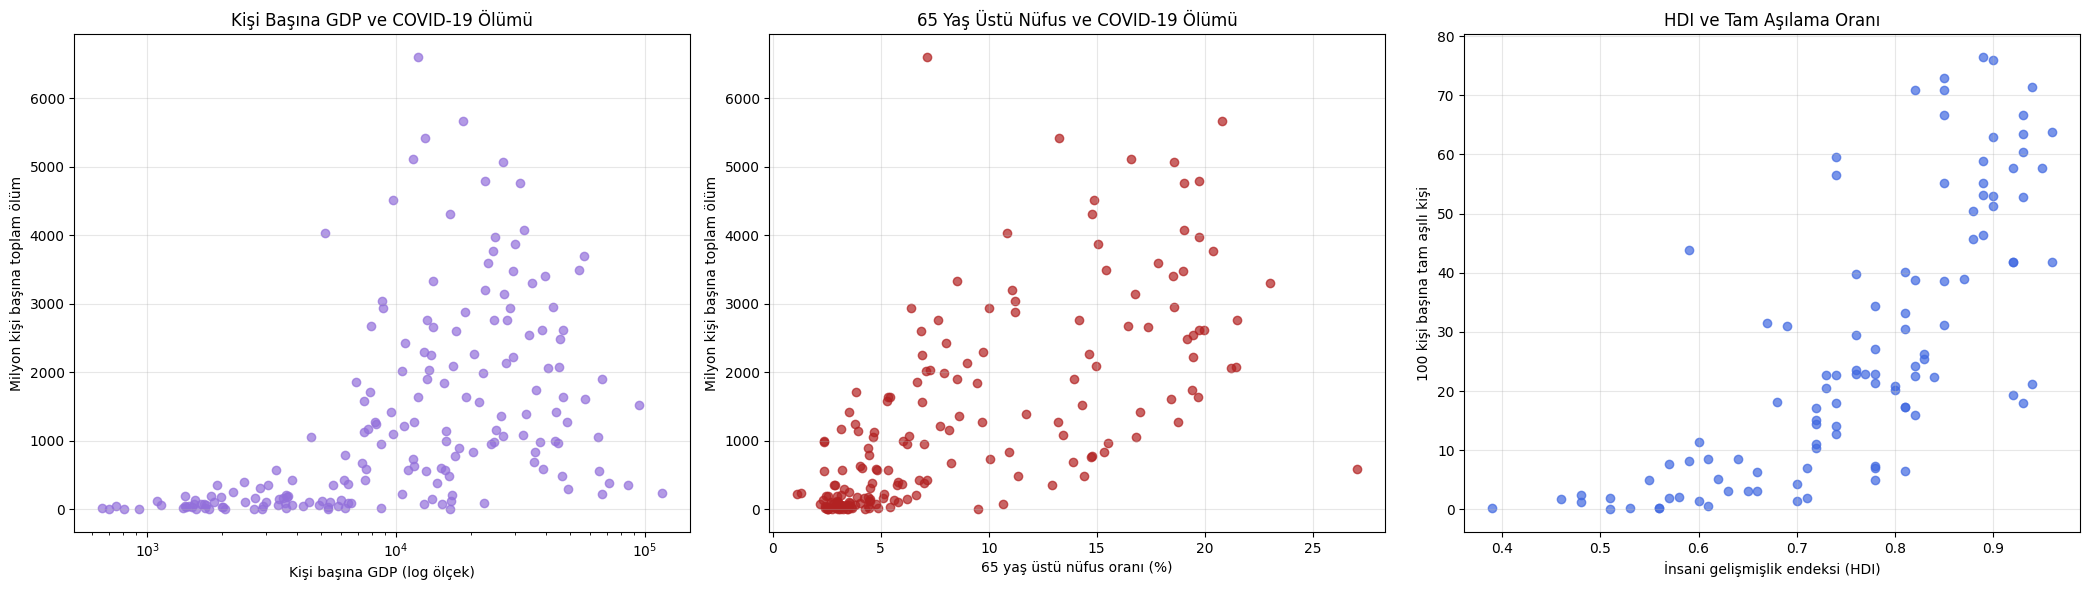

In [20]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)

axes[0].scatter(
    gdp_death_data['gdp_per_capita'],
    gdp_death_data['total_deaths_per_million'],
    color='mediumpurple',
    alpha=0.7
)

axes[0].set_xscale('log')

axes[0].set_title(
    'Kişi Başına GDP ve COVID-19 Ölümü'
)

axes[0].set_xlabel('Kişi başına GDP (log ölçek)')
axes[0].set_ylabel('Milyon kişi başına toplam ölüm')
axes[0].grid(alpha=0.3)

axes[1].scatter(
    age_death_data['aged_65_older'],
    age_death_data['total_deaths_per_million'],
    color='firebrick',
    alpha=0.7
)

axes[1].set_title(
    '65 Yaş Üstü Nüfus ve COVID-19 Ölümü'
)

axes[1].set_xlabel('65 yaş üstü nüfus oranı (%)')
axes[1].set_ylabel('Milyon kişi başına toplam ölüm')
axes[1].grid(alpha=0.3)

axes[2].scatter(
    hdi_vaccination_data['human_development_index'],
    hdi_vaccination_data[
        'people_fully_vaccinated_per_hundred'
    ],
    color='royalblue',
    alpha=0.7
)

axes[2].set_title(
    'HDI ve Tam Aşılama Oranı'
)

axes[2].set_xlabel('İnsani gelişmişlik endeksi (HDI)')
axes[2].set_ylabel('100 kişi başına tam aşılı kişi')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
#üç noktanın korelasyon grafiğini hesaplıyoruz
main_correlations = pd.Series({
    'Logaritmik kişi başına GDP ve ölüm': (
        np.log10(
            gdp_death_data['gdp_per_capita']
        )
        .corr(
            gdp_death_data['total_deaths_per_million']
        )
    ),
    '65 yaş üstü nüfus ve ölüm': (
        age_death_data['aged_65_older']
        .corr(
            age_death_data['total_deaths_per_million']
        )
    ),
    'HDI ve tam aşılama': (
        hdi_vaccination_data['human_development_index']
        .corr(
            hdi_vaccination_data[
                'people_fully_vaccinated_per_hundred'
            ]
        )
    )
})

print(main_correlations.round(3))

Logaritmik kişi başına GDP ve ölüm    0.498
65 yaş üstü nüfus ve ölüm             0.683
HDI ve tam aşılama                    0.741
dtype: float64


In [23]:
context_death_data = (
    country_profile
    .merge(
        death_outcome,
        on='location',
        how='inner'
    )
)

context_columns = [
    'median_age',
    'aged_70_older',
    'life_expectancy',
    'population_density',
    'hospital_beds_per_thousand',
    'extreme_poverty',
    'diabetes_prevalence',
    'cardiovasc_death_rate',
    'female_smokers',
    'male_smokers',
    'handwashing_facilities'
]

context_correlation_rows = []

for column in context_columns:
    pair_data = context_death_data[
        [
            column,
            'total_deaths_per_million'
        ]
    ].dropna()

    if column == 'population_density':
        correlation_value = (
            np.log10(pair_data[column])
            .corr(
                pair_data['total_deaths_per_million']
            )
        )
    else:
        correlation_value = (
            pair_data[column]
            .corr(
                pair_data['total_deaths_per_million']
            )
        )

    context_correlation_rows.append(
        {
            'gosterge': column,
            'karsilastirilan_ulke_sayisi': len(pair_data),
            'olum_korelasyonu': correlation_value
        }
    )

context_correlation_summary = (
    pd.DataFrame(context_correlation_rows)
    .sort_values(
        'olum_korelasyonu',
        ascending=False
    )
)

print(context_correlation_summary.round(3))

                      gosterge  karsilastirilan_ulke_sayisi  olum_korelasyonu
0                   median_age                          183             0.679
1                aged_70_older                          182             0.678
8               female_smokers                          146             0.578
10      handwashing_facilities                           95             0.552
2              life_expectancy                          194             0.533
4   hospital_beds_per_thousand                          172             0.328
9                 male_smokers                          144             0.137
3           population_density                          191            -0.001
6          diabetes_prevalence                          192            -0.047
7        cardiovasc_death_rate                          186            -0.196
5              extreme_poverty                          123            -0.493


Isı haritasında karşılaştırılan ülke sayısı: 69


,log_gdp_per_capita,human_development_index,aged_65_older,life_expectancy,hospital_beds_per_thousand,extreme_poverty,total_deaths_per_million,people_fully_vaccinated_per_hundred
log_gdp_per_capita,1.000,0.973,0.765,0.860,0.498,-0.778,0.534,0.750
human_development_index,0.973,1.000,0.808,0.894,0.548,-0.805,0.572,0.745
aged_65_older,0.765,0.808,1.000,0.727,0.602,-0.546,0.675,0.683
life_expectancy,0.860,0.894,0.727,1.000,0.365,-0.733,0.472,0.698
hospital_beds_per_thousand,0.498,0.548,0.602,0.365,1.000,-0.412,0.410,0.321
extreme_poverty,-0.778,-0.805,-0.546,-0.733,-0.412,1.000,-0.459,-0.528
total_deaths_per_million,0.534,0.572,0.675,0.472,0.410,-0.459,1.000,0.415
people_fully_vaccinated_per_hundred,0.750,0.745,0.683,0.698,0.321,-0.528,0.415,1.000


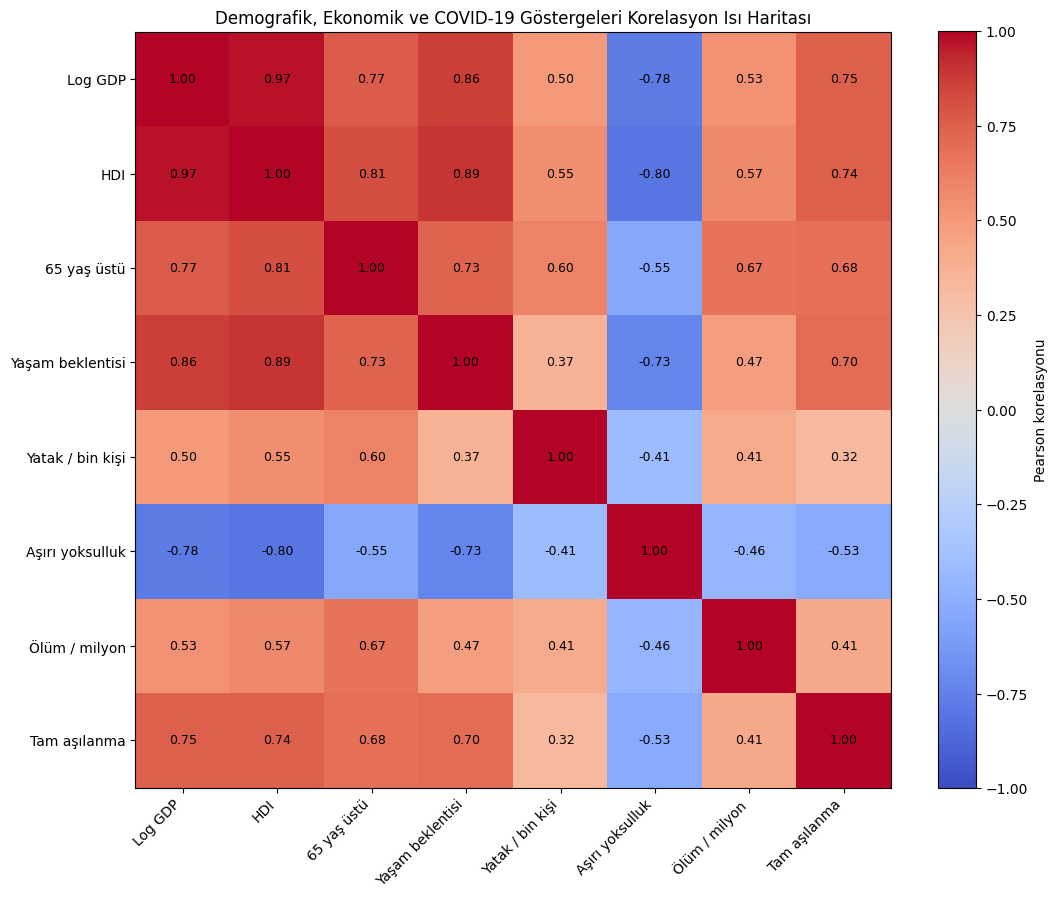

In [24]:
heatmap_data = (
    country_profile[
        [
            'location',
            'gdp_per_capita',
            'human_development_index',
            'aged_65_older',
            'life_expectancy',
            'hospital_beds_per_thousand',
            'extreme_poverty'
        ]
    ]
    .merge(
        death_outcome,
        on='location',
        how='inner'
    )
    .merge(
        vaccination_outcome,
        on='location',
        how='inner'
    )
    .dropna()
    .copy()
)

heatmap_data['log_gdp_per_capita'] = np.log10(
    heatmap_data['gdp_per_capita']
)

heatmap_columns = [
    'log_gdp_per_capita',
    'human_development_index',
    'aged_65_older',
    'life_expectancy',
    'hospital_beds_per_thousand',
    'extreme_poverty',
    'total_deaths_per_million',
    'people_fully_vaccinated_per_hundred'
]

heatmap_labels = [
    'Log GDP',
    'HDI',
    '65 yaş üstü',
    'Yaşam beklentisi',
    'Yatak / bin kişi',
    'Aşırı yoksulluk',
    'Ölüm / milyon',
    'Tam aşılanma'
]

correlation_matrix = (
    heatmap_data[heatmap_columns]
    .corr()
)

print(
    'Isı haritasında karşılaştırılan ülke sayısı:',
    len(heatmap_data)
)

display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(11, 9))

image = ax.imshow(
    correlation_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(heatmap_labels))
)

ax.set_yticks(
    np.arange(len(heatmap_labels))
)

ax.set_xticklabels(
    heatmap_labels,
    rotation=45,
    ha='right'
)

ax.set_yticklabels(heatmap_labels)

for row in range(len(heatmap_labels)):
    for column in range(len(heatmap_labels)):
        ax.text(
            column,
            row,
            f'{correlation_matrix.iloc[row, column]:.2f}',
            ha='center',
            va='center',
            fontsize=9
        )

fig.colorbar(
    image,
    ax=ax,
    label='Pearson korelasyonu'
)

ax.set_title(
    'Demografik, Ekonomik ve COVID-19 Göstergeleri Korelasyon Isı Haritası'
)

plt.tight_layout()
plt.show()

## Bulgular ve Dashboard Kararları

### Veri kalitesi ve ülke profili

- Demografik, ekonomik, sağlık riski ve altyapı göstergeleri ülke bazında sabit bilgiler olarak incelenmiştir.
- Sabit göstergelerde zaman içinde birden fazla farklı değer ve tanımlanan mantıksal sınırların dışında anormal kayıt bulunmamıştır.
- Her ülke için tek satırlık `country_profile` tablosu oluşturulmuştur.
- Bir ülkenin bir göstergesi eksikse, ülke yalnızca o göstergenin kullanıldığı analizden çıkarılmıştır. Tüm göstergeleri eksik olmadığı sürece ülke analizden tamamen çıkarılmamıştır.

### Ölüm ve aşılanma karşılaştırmaları

- Milyon kişi başına toplam COVID-19 ölümü için en geniş ortak kapsam, 4 Ağustos 2024 tarihinde 194 ülkede bulunmuştur.
- Tam aşılama oranı için en geniş ortak kapsam, 16 Ağustos 2021 tarihinde 106 ülkede bulunmuştur.
- Ölüm ve aşılama göstergeleri için farklı tarihler kullanılmıştır; her gösterge kendi en geniş ülke kapsamına sahip tarihte değerlendirilmiştir.

### Ana ilişkiler

- Logaritmik kişi başına GDP ile milyon kişi başına toplam COVID-19 ölümü arasında orta düzeyde pozitif ilişki görülmüştür (`r = 0.498`, 186 ülke).
- 65 yaş üstü nüfus oranı ile milyon kişi başına toplam COVID-19 ölümü arasında güçlü pozitif ilişki görülmüştür (`r = 0.683`, 182 ülke).
- HDI ile tam aşılama oranı arasında güçlü pozitif ilişki görülmüştür (`r = 0.741`, 105 ülke).
- HDI düzeyi yüksek ülkelerde tam aşılama oranları genel olarak daha yüksektir. Bu ilişki; sağlık altyapısı, gelir, lojistik kapasite ve aşı erişimi gibi birlikte değişen faktörleri yansıtabilir.

### Yardımcı göstergeler

- Ortanca yaş ve 70 yaş üstü nüfus oranı da milyon kişi başına toplam ölümle güçlü pozitif ilişki göstermiştir.
- Kadın sigara oranı, el yıkama imkânı ve yaşam beklentisi bazı ülkelerde ölüm göstergesiyle pozitif ilişki göstermiştir. Bu sonuçlar doğrudan nedensel etki olarak yorumlanmamalıdır.
- Aşırı yoksulluk oranı ile bildirilen COVID-19 ölümü arasında negatif ilişki görülmüştür. Ülkeler arası raporlama farkı, yaş yapısı, sağlık hizmetine erişim ve gelişmişlik düzeyi bu ilişkiyi etkileyebilir.
- Diyabet yaygınlığı ve logaritmik nüfus yoğunluğu ile milyon kişi başına toplam ölüm arasında çok zayıf ilişki görülmüştür.

### Korelasyon ısı haritası

- Korelasyon ısı haritasında GDP, HDI, yaşlı nüfus oranı ve yaşam beklentisinin birbiriyle güçlü ilişkiler taşıdığı görülmüştür.
- Isı haritasında tüm seçili göstergeleri eksiksiz bulunan 69 ülke kullanılmıştır.
- Korelasyonlar ülke düzeyindeki birliktelikleri gösterir; bireysel risk, nedensel etki veya politika başarısı olarak yorumlanmamalıdır.

### Dashboard Kararları

- Dashboard’da GDP–ölüm, 65 yaş üstü nüfus–ölüm ve HDI–tam aşılama için üç dağılım grafiği kullanılacaktır.
- Korelasyon ısı haritası, seçili demografik ve ekonomik göstergelerin birlikte incelenmesi için kullanılacaktır.
- Grafiklerde her nokta bir ülkeyi temsil eder.
- Regression veya tahmin modeli bu projenin kapsamına alınmamıştır.